Descargando datos desde 2010...


[*********************100%***********************]  7 of 7 completed



Iniciando Walk-Forward con ventana móvil de 156 semanas...

Imagen de la tabla guardada como 'tabla_metricas.png'


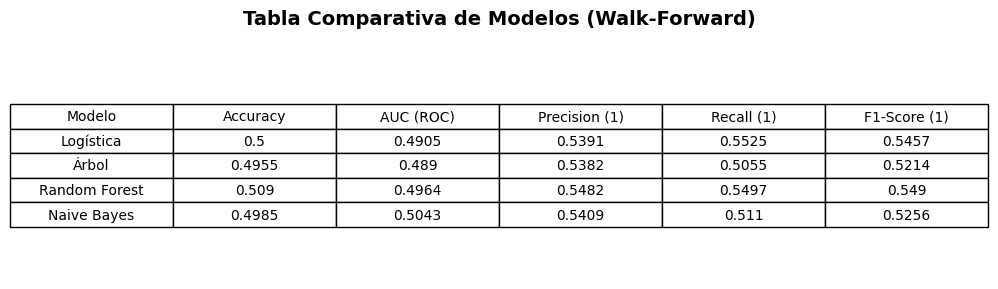

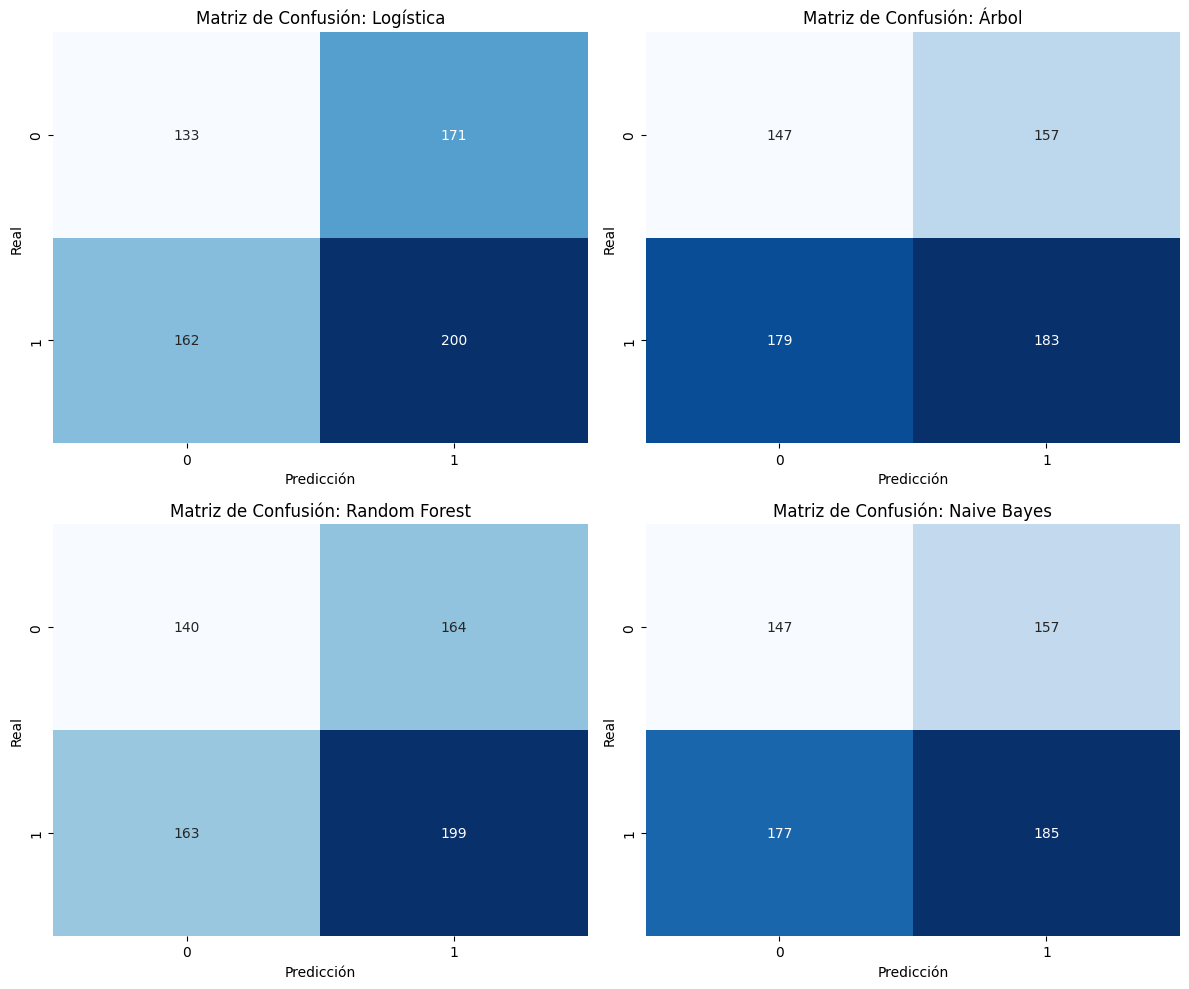

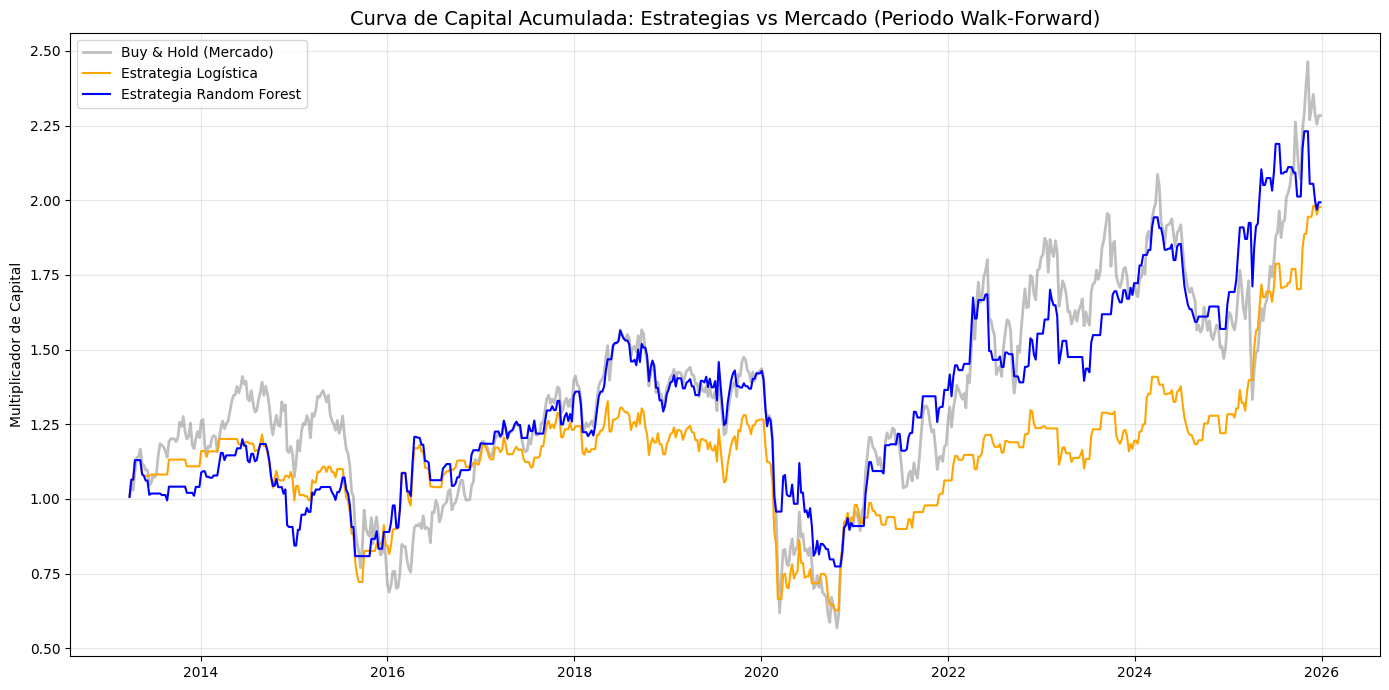

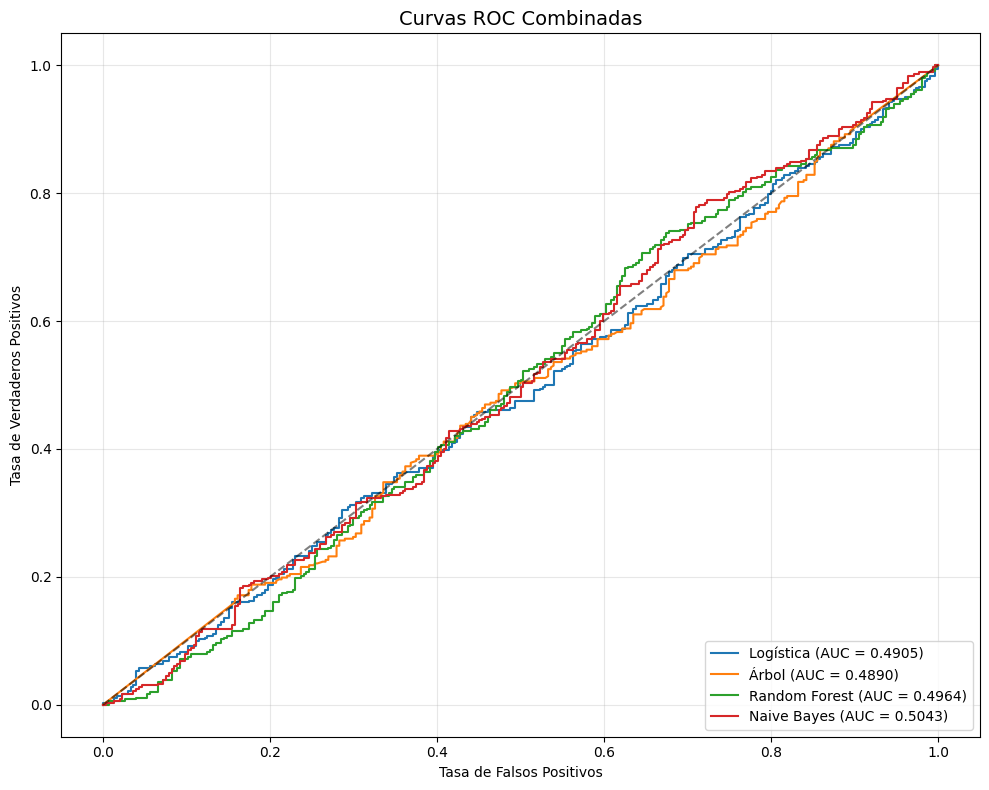

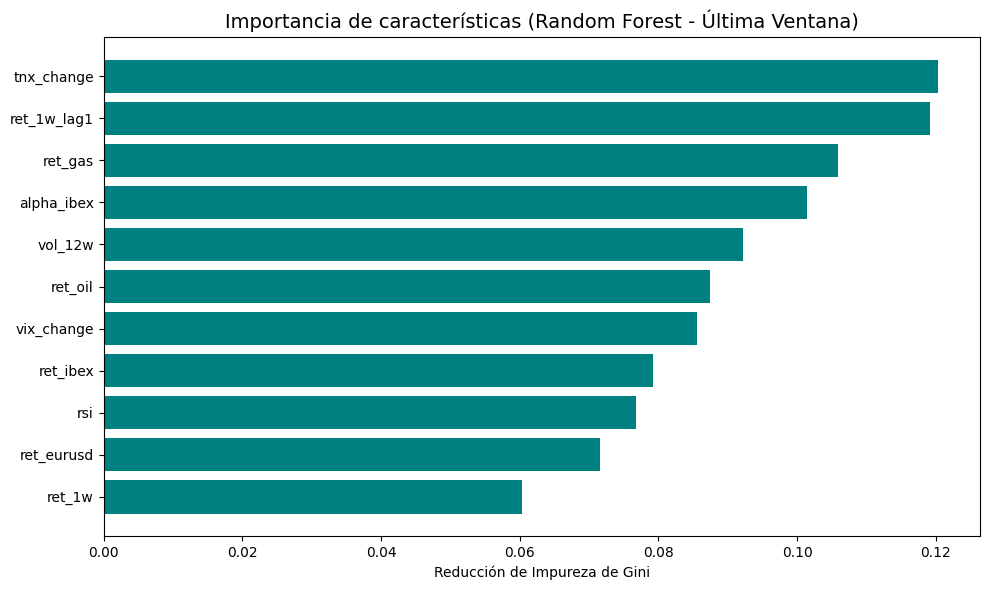

In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score, confusion_matrix, roc_curve
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB

import warnings
warnings.filterwarnings('ignore')

# =========================================
# 1. DESCARGA DE DATOS
# =========================================
tickers = ["REP.MC", "CL=F", "^IBEX", "NG=F", "EURUSD=X", "^VIX", "^TNX"]
print("Descargando datos desde 2010...")
raw_data = yf.download(tickers, start="2010-01-01", end="2026-01-01")

df_daily = raw_data['Close'].copy()
df_daily.columns = ['Oil', 'EurUsd', 'Gas', 'Repsol', 'Ibex', 'TNX', 'VIX']

# Rellenar festivos distintos entre mercados antes de resamplear
df_daily = df_daily.ffill()

# =========================================
# 2. DATOS SEMANALES Y FEATURES 
# =========================================
df = df_daily.resample('W-FRI').last().dropna()

# Retornos principales
df['ret_1w'] = df['Repsol'].pct_change()
df['ret_oil'] = df['Oil'].pct_change()
df['ret_gas'] = df['Gas'].pct_change()
df['ret_ibex'] = df['Ibex'].pct_change()
df['ret_eurusd'] = df['EurUsd'].pct_change()

# Macros 
df['vix_change'] = df['VIX'].diff()
df['tnx_change'] = df['TNX'].diff()

# Indicadores Técnicos y Alpha
df['alpha_ibex'] = df['ret_1w'] - df['ret_ibex']
df['ret_1w_lag1'] = df['ret_1w'].shift(1)
df['vol_12w'] = df['ret_1w'].rolling(12).std()

# RSI
delta = df['Repsol'].diff()
gain = delta.where(delta > 0, 0)
loss = -delta.where(delta < 0, 0)
avg_gain = gain.ewm(com=13, adjust=False).mean()
avg_loss = loss.ewm(com=13, adjust=False).mean()
rs = avg_gain / avg_loss
df['rsi'] = 100 - (100 / (1 + rs))

# Target: 1 si sube la semana que viene, 0 si baja o se mantiene
df['target'] = (df['ret_1w'].shift(-1) > 0).astype(int)

# Limpieza
df = df.dropna()
df = df.iloc[:-1] 

# Variables finales 
features = [
    'ret_1w', 'ret_oil', 'ret_gas', 'ret_ibex', 'ret_eurusd', 
    'vix_change', 'tnx_change', 'alpha_ibex', 'ret_1w_lag1', 'vol_12w', 'rsi'
]
X = df[features]
y = df['target']

# =========================================
# 3. WALK-FORWARD VALIDATION (Rolling Window)
# =========================================
window_size = 156 # Entrenamos siempre con los últimos 3 años (156 semanas)
print(f"\nIniciando Walk-Forward con ventana móvil de {window_size} semanas...")

# Modelos
models = {
    "Logística": LogisticRegression(C=1.0, max_iter=1000, class_weight='balanced'),
    "Árbol": DecisionTreeClassifier(max_depth=5, min_samples_split=10, class_weight='balanced', random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=5, min_samples_leaf=5, class_weight='balanced', random_state=42),
    "Naive Bayes": GaussianNB()
}


predictions = {name: [] for name in models.keys()}
probabilities = {name: [] for name in models.keys()}
y_true = []
test_dates = []

for i in range(len(df) - window_size):
    # Ventana de entrenamiento
    X_train_wf = X.iloc[i : i + window_size]
    y_train_wf = y.iloc[i : i + window_size]
    
    # Semana de test
    X_test_step = X.iloc[i + window_size : i + window_size + 1]
    y_true.append(y.iloc[i + window_size])
    test_dates.append(X.index[i + window_size])
    
    # Escalado dinámico
    scaler = StandardScaler()
    X_train_wf_scaled = scaler.fit_transform(X_train_wf)
    X_test_step_scaled = scaler.transform(X_test_step)
    
    for name, model in models.items():
        model.fit(X_train_wf_scaled, y_train_wf)
        pred = model.predict(X_test_step_scaled)[0]
        prob = model.predict_proba(X_test_step_scaled)[0, 1]
        
        predictions[name].append(pred)
        probabilities[name].append(prob)

# =========================================
# 4. CÁLCULO DE MÉTRICAS
# =========================================
results = []
for name in predictions.keys():
    y_pred = predictions[name]
    y_prob = probabilities[name]
    
    acc = accuracy_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_prob)
    report = classification_report(y_true, y_pred, output_dict=True, zero_division=0)
    
    results.append([
        name, round(acc, 4), round(auc, 4), 
        round(report['1']['precision'], 4), 
        round(report['1']['recall'], 4), 
        round(report['1']['f1-score'], 4)
    ])

df_results = pd.DataFrame(results, columns=["Modelo", "Accuracy", "AUC (ROC)", "Precision (1)", "Recall (1)", "F1-Score (1)"])

# =========================================
# 5. VISUALIZACIONES
# =========================================
# 5.1 Tabla de Resultados como Imagen
fig, ax = plt.subplots(figsize=(10, 3))
ax.axis('tight')
ax.axis('off')
tabla = ax.table(cellText=df_results.values, colLabels=df_results.columns, loc='center', cellLoc='center')
tabla.auto_set_font_size(False)
tabla.set_fontsize(10)
tabla.scale(1.2, 1.5)
plt.title("Tabla Comparativa de Modelos (Walk-Forward)", pad=20, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('tabla_metricas.png', dpi=300, bbox_inches='tight')
print("\nImagen de la tabla guardada como 'tabla_metricas.png'")
plt.show()

# 5.2 MATRICES DE CONFUSIÓN (Todos los algoritmos ajustados a 2x2)
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

for idx, name in enumerate(predictions.keys()):
    cm = confusion_matrix(y_true, predictions[name])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx], cbar=False)
    axes[idx].set_title(f'Matriz de Confusión: {name}')
    axes[idx].set_xlabel('Predicción')
    axes[idx].set_ylabel('Real')

plt.tight_layout()
plt.show()

# 5.3 Curva de Capital (Equity Curve)
df_test = df.loc[test_dates].copy()
df_test['Retorno_Real'] = df_test['ret_1w'].shift(-1).fillna(0)

df_test['Buy_Hold'] = (1 + df_test['Retorno_Real']).cumprod()

plt.figure(figsize=(14, 7))
plt.plot(df_test.index, df_test['Buy_Hold'], label='Buy & Hold (Mercado)', color='gray', alpha=0.5, linewidth=2)

colores = ['orange', 'green', 'blue', 'purple']
for idx, name in enumerate(predictions.keys()):
    estrategia_ret = np.where(np.array(predictions[name]) == 1, df_test['Retorno_Real'], 0)
    equity = (1 + estrategia_ret).cumprod()
    
    # Destacamos solo las estrategias más estables en el gráfico
    if name in ['Logística', 'Random Forest']:
        plt.plot(df_test.index, equity, label=f'Estrategia {name}', color=colores[idx], linewidth=1.5)

plt.title("Curva de Capital Acumulada: Estrategias vs Mercado (Periodo Walk-Forward)", fontsize=14)
plt.ylabel("Multiplicador de Capital")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 5.4 Curvas ROC Combinadas
plt.figure(figsize=(10, 8))
for name in predictions.keys():
    fpr, tpr, _ = roc_curve(y_true, probabilities[name])
    auc_val = roc_auc_score(y_true, probabilities[name])
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc_val:.4f})')

plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.title('Curvas ROC Combinadas', fontsize=14)
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 5.5 Importancia de Características (Del último Random Forest)
importances = models['Random Forest'].feature_importances_
feat_imp = pd.DataFrame({'Variable': features, 'Importancia': importances}).sort_values(by='Importancia', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(feat_imp['Variable'], feat_imp['Importancia'], color='teal')
plt.title("Importancia de características (Random Forest - Última Ventana)", fontsize=14)
plt.xlabel("Reducción de Impureza de Gini")
plt.tight_layout()
plt.show()